In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

In [2]:
addArchRThreads(threads = 32)

Setting default number of Parallel threads to 32.



In [3]:
out_dir = '../../results/04_single_cell_access_atac/12_find_markers'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [4]:
proj <- loadArchRProject("../../results/04_single_cell_access_atac/10_create_archr_project", showLogo = FALSE)

Successfully loaded ArchRProject!



In [5]:
obj <- readRDS("../../results/04_single_cell_access_atac/11_create_seurat/obj.rds")

In [6]:
obj

An object of class Seurat 
138953 features across 2024 samples within 1 assay 
Active assay: ATAC (138953 features, 137630 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: lsi, umap_atac

In [7]:
## add clusters to ArchR project
clusters <- obj@meta.data[rownames(proj@cellColData), "seurat_clusters"]

proj <- addCellColData(proj, 
                       data = as.character(clusters), 
                       name = "Clusters", 
                       cells = rownames(proj@cellColData), 
                       force = TRUE)

In [8]:
## add UMAP embedding
embedding <- obj@reductions$umap@cell.embeddings
embedding <- embedding[rownames(proj@cellColData), ]

colnames(embedding) <- c("LSI#UMAP_Dimension_1",
                         "LSI#UMAP_Dimension_2")

proj@embeddings[["umap"]] <- SimpleList(df = as.data.frame(embedding),
                                        params = NULL)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-35b98265327aab-Date-2026-01-12_Time-02-22-56.824871.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-35b98265327aab-Date-2026-01-12_Time-02-22-56.824871.log



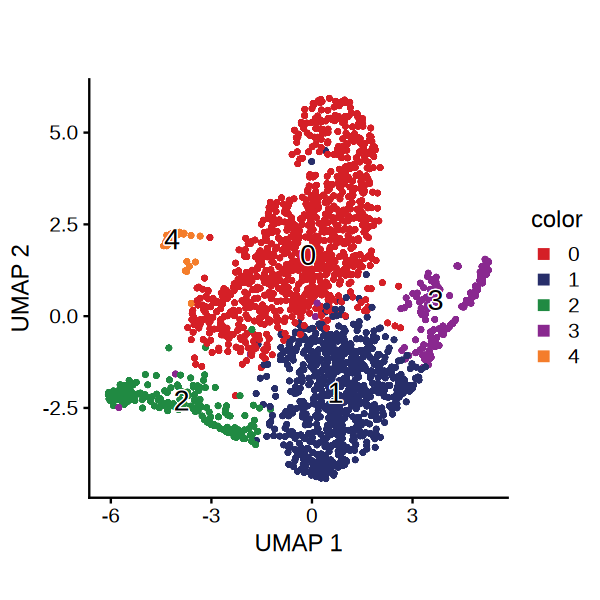

In [9]:
p <- plotEmbedding(ArchRProj = proj,
                   embedding = "umap",
                   colorBy = "cellColData",
                   name = "Clusters",
                   baseSize = 50,
                   size = 3,
                  labelSize = 6,
                  labelAsFactors = FALSE) +
    theme_cowplot() +
    xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

options(repr.plot.height = 5, repr.plot.width = 5)

print(p)

In [10]:
markersGS <- getMarkerFeatures(
    ArchRProj = proj, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-35b98266b23902-Date-2026-01-12_Time-02-23-09.32568.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2026-01-12 02:23:09.813403 : Matching Known Biases, 0.004 mins elapsed.

###########
2026-01-12 02:23:35.219915 : Completed Pairwise Tests, 0.427 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-35b98266b23902-Date-2026-01-12_Time-02-23-09.32568.log



In [11]:
heatmapGS <- plotMarkerHeatmap(
  seMarker = markersGS, 
  cutOff = "FDR <= 0.05 & Log2FC >= 0.5", 
  #labelMarkers = markerGenes,
  transpose = TRUE
)

ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-35b9827473af9c-Date-2026-01-12_Time-02-23-40.215007.log
If there is an issue, please report to github with logFile!

Printing Top Marker Genes:

0:

	Gm28836, Hspd1, Hspe1, Aox1, Nop58, D630023F18Rik, Fcamr, Gm28609, Fmo2, Fmo6, Fmo3, Gm37864, Mpc2, Gm36937, Srp9

1:

	Rgs13, Gpr142, Or2w2, 1700092E19Rik, Gm31577, Trdv4, Gm33299, Gm36988, Zfp268, Gm42931, Trbv13-3, Vmn1r62, Vmn2r45, Gm36431, Semp2l2a

2:

	Tnnt2, ENSMUSG00000121448, 4930459C07Rik, Gm34777, Gm48884, Gm56944, Spns3, Slfn2, Fgd3, Gm36377, Tgm1, Tnfrsf11b, Mroh4, Muc4, Kalrn

3:

	Agap1, Gm28792, Syne1, ENSMUSG00000121406, Gm49002, Dnah5, Tcf4, Gm13661, 1700094M23Rik, Tox, Kcnq4, Fgl2, Ppp2r2c, Hfm1, Gm26897

4:

	Gm28836, Hspd1, Hspe1, Aox1, Nop58, D630023F18Rik, Agap1, Fcamr, Gm28609, Tnnt2, Rgs13, Gm28792, Fmo2, Fmo6, Fmo3

Identified 405 markers!



 [1] "Gm28836"            "Hspd1"              "Hspe1"             
 [4] "Aox1"               "Nop58"              "D630023F18Rik"     
 [7] "Fcamr"              "Gm28609"            "Fmo2"              
[10] "Fmo6"               "Fmo3"               "Gm37864"           
[13] "Mpc2"               "Gm36937"            "Srp9"              
[16] "Rgs13"              "Gpr142"             "Or2w2"             
[19] "1700092E19Rik"      "Gm31577"            "Trdv4"             
[22] "Gm33299"            "Gm36988"            "Zfp268"            
[25] "Gm42931"            "Trbv13-3"           "Vmn1r62"           
[28] "Vmn2r45"            "Gm36431"            "Semp2l2a"          
[31] "Tnnt2"              "ENSMUSG00000121448" "4930459C07Rik"     
[34] "Gm34777"            "Gm48884"            "Gm56944"           
[37] "Spns3"              "Slfn2"              "Fgd3"              
[40] "Gm36377"            "Tgm1"               "Tnfrsf11b"         
[43] "Mroh4"              "Muc4"               "

Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-35b9827473af9c-Date-2026-01-12_Time-02-23-40.215007.log



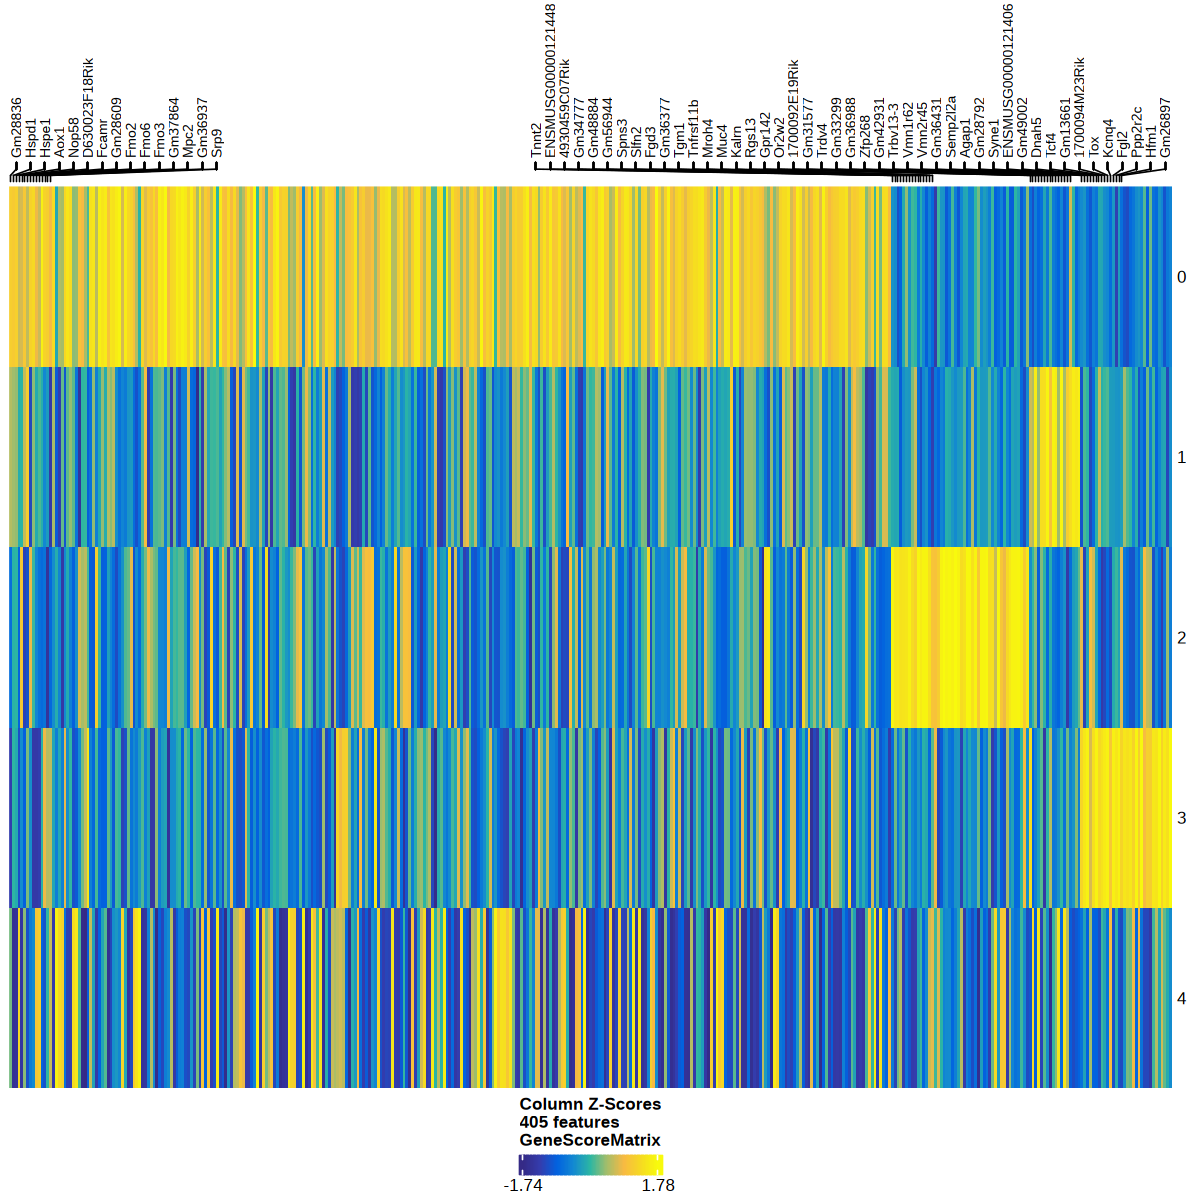

In [12]:
options(repr.plot.height = 10, repr.plot.width = 10)
ComplexHeatmap::draw(heatmapGS, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [27]:
proj <- addImputeWeights(proj, dimsToUse = 2:15, scaleDims = TRUE)

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-35b9822d0bc33a-Date-2026-01-12_Time-02-30-35.764077.log
If there is an issue, please report to github with logFile!



2026-01-12 02:30:36.038358 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.



In [28]:
markerGenes  <- c(
    "Aqp3",  # NK cells
    "Scgb1a1",  # Club cells
    "Foxj1"  # Ciliated cells
    )

In [32]:
p <- plotEmbedding(
    ArchRProj = proj, 
    colorBy = "GeneScoreMatrix", 
    name = markerGenes, 
    embedding = "umap",
    quantCut = c(0.01, 0.95),
    imputeWeights = NULL
)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-35b982519fac43-Date-2026-01-12_Time-02-31-32.687146.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2026-01-12 02:31:33.090484 : 

1 


Plotting Embedding

1 
2 
3 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-35b982519fac43-Date-2026-01-12_Time-02-31-32.687146.log



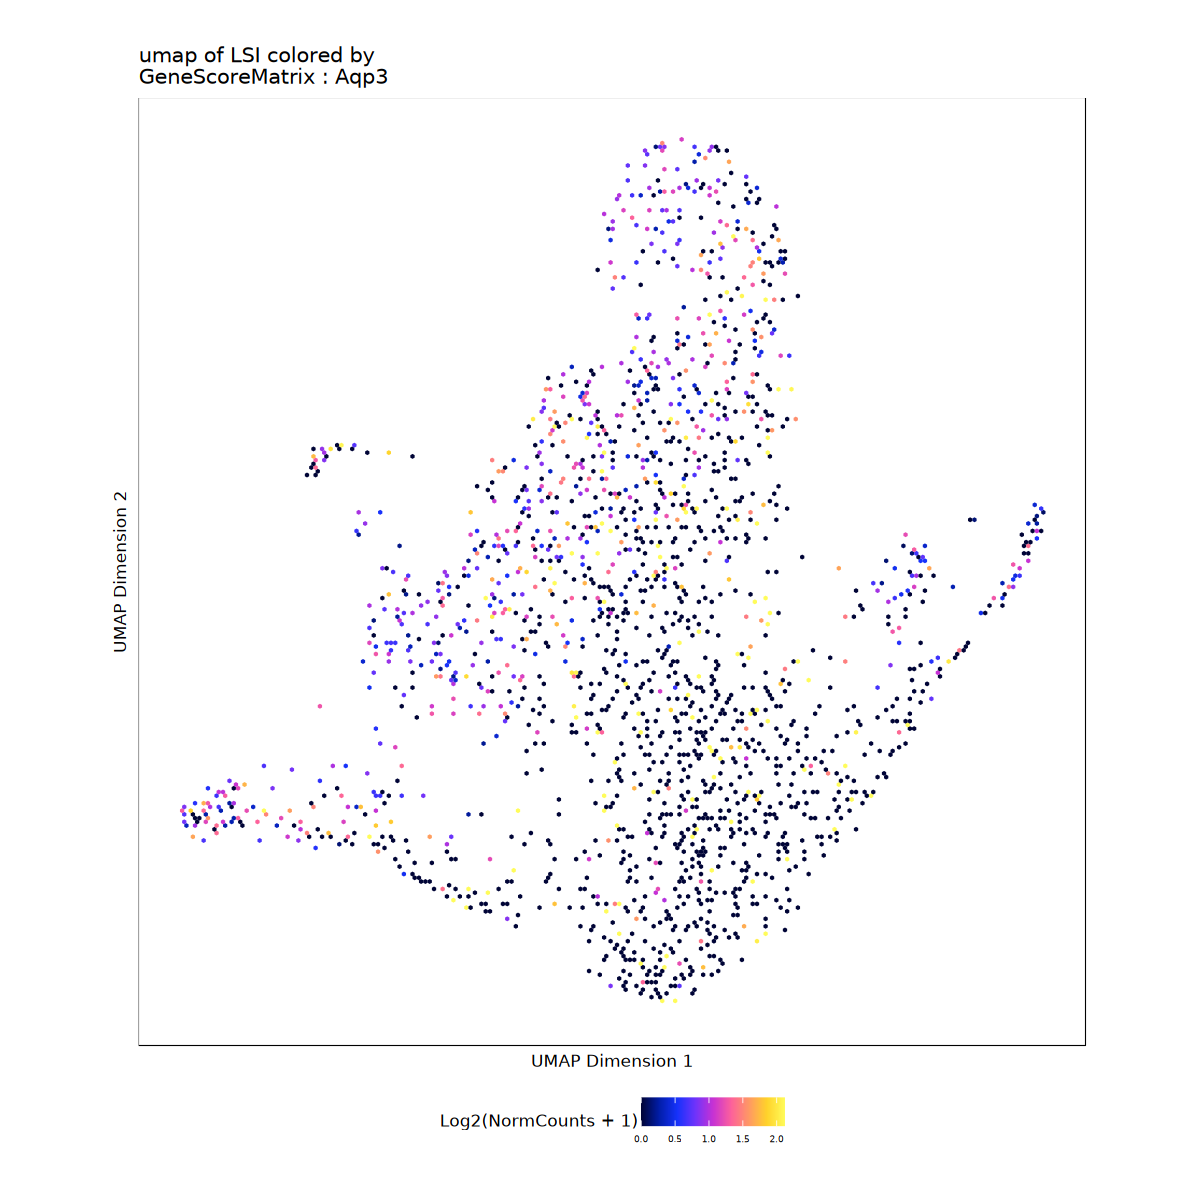

In [33]:
options(repr.plot.height = 10, repr.plot.width = 10)
print(p$Aqp3)

In [37]:
p <- plotBrowserTrack(
    ArchRProj = proj, 
    groupBy = "Clusters", 
    geneSymbol = markerGenes, 
    upstream = 10000,
    downstream = 10000
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-35b98278263197-Date-2026-01-12_Time-02-34-19.486442.log
If there is an issue, please report to github with logFile!



2026-01-12 02:34:19.808798 : Validating Region, 0.005 mins elapsed.



GRanges object with 3 ranges and 2 metadata columns:
      seqnames              ranges strand |            gene_id      symbol
         <Rle>           <IRanges>  <Rle> |        <character> <character>
  [1]     chr4   41092722-41098183      - | ENSMUSG00000028435        Aqp3
  [2]    chr19     9061000-9065322      - | ENSMUSG00000024653     Scgb1a1
  [3]    chr11 116221530-116226225      - | ENSMUSG00000034227       Foxj1
  -------
  seqinfo: 21 sequences from an unspecified genome; no seqlengths


2026-01-12 02:34:19.892195 : Adding Bulk Tracks (1 of 3), 0.007 mins elapsed.

Getting Region From Arrow Files 1 of 1

2026-01-12 02:34:20.385304 : Adding Feature Tracks (1 of 3), 0.015 mins elapsed.

2026-01-12 02:34:20.480002 : Adding Gene Tracks (1 of 3), 0.017 mins elapsed.

2026-01-12 02:34:20.715846 : Plotting, 0.021 mins elapsed.

2026-01-12 02:34:21.145575 : Adding Bulk Tracks (2 of 3), 0.028 mins elapsed.

Getting Region From Arrow Files 1 of 1

2026-01-12 02:34:21.609305 : Adding Feature Tracks (2 of 3), 0.035 mins elapsed.

2026-01-12 02:34:21.672005 : Adding Gene Tracks (2 of 3), 0.036 mins elapsed.

2026-01-12 02:34:21.920917 : Plotting, 0.041 mins elapsed.

2026-01-12 02:34:22.337748 : Adding Bulk Tracks (3 of 3), 0.048 mins elapsed.

Getting Region From Arrow Files 1 of 1

2026-01-12 02:34:22.825456 : Adding Feature Tracks (3 of 3), 0.056 mins elapsed.

2026-01-12 02:34:22.889848 : Adding Gene Tracks (3 of 3), 0.057 mins elapsed.

2026-01-12 02:34:23.168761 : Plotting, 0

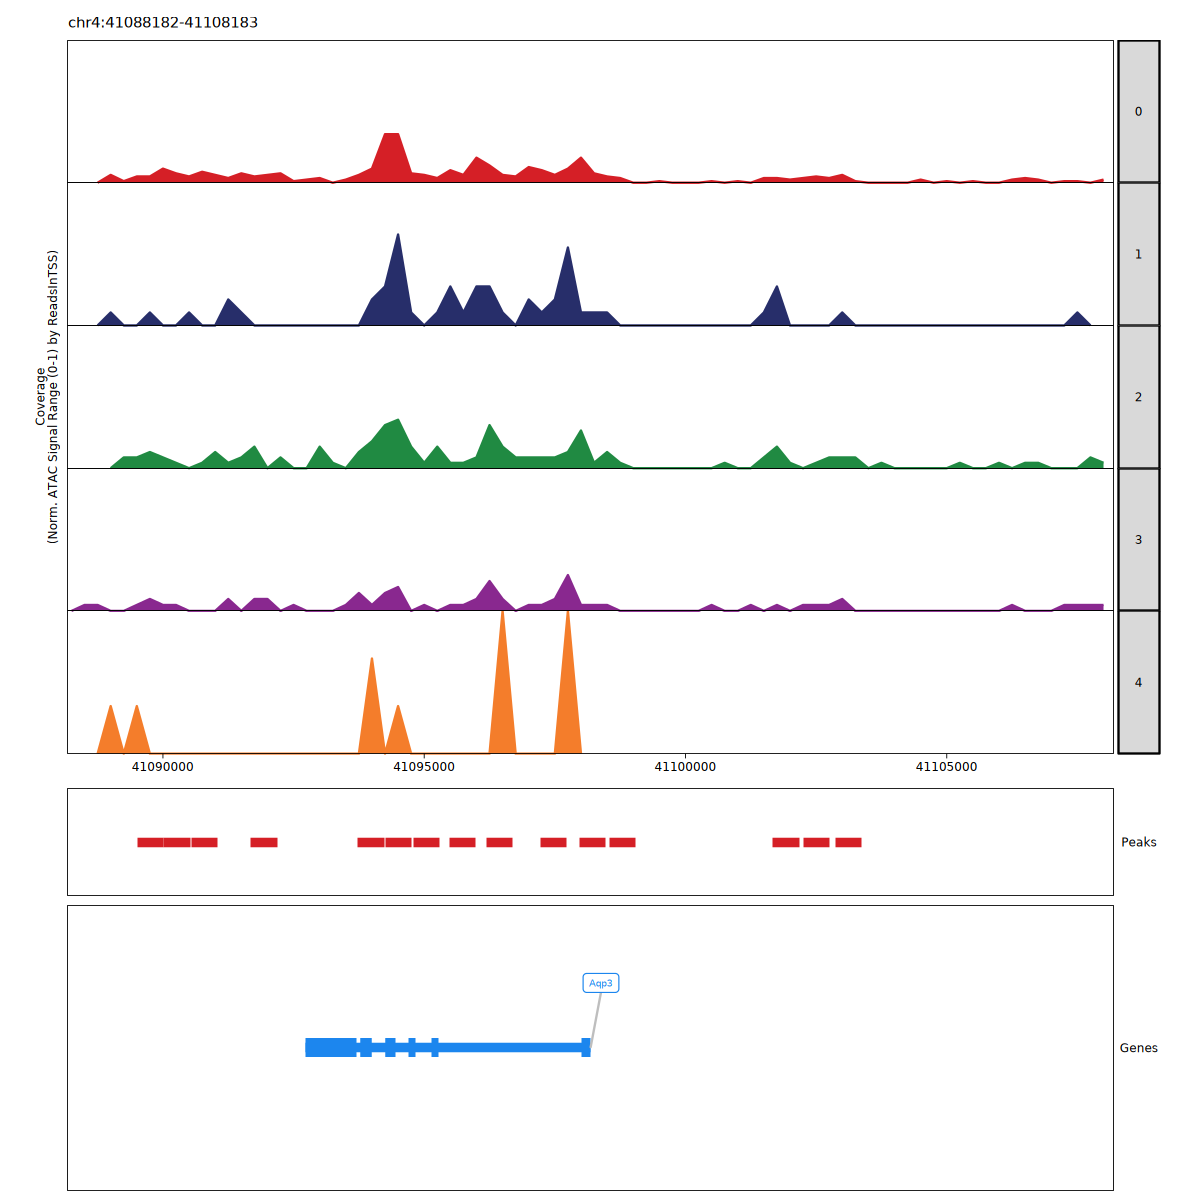

In [38]:
grid::grid.newpage()
grid::grid.draw(p$Aqp3)

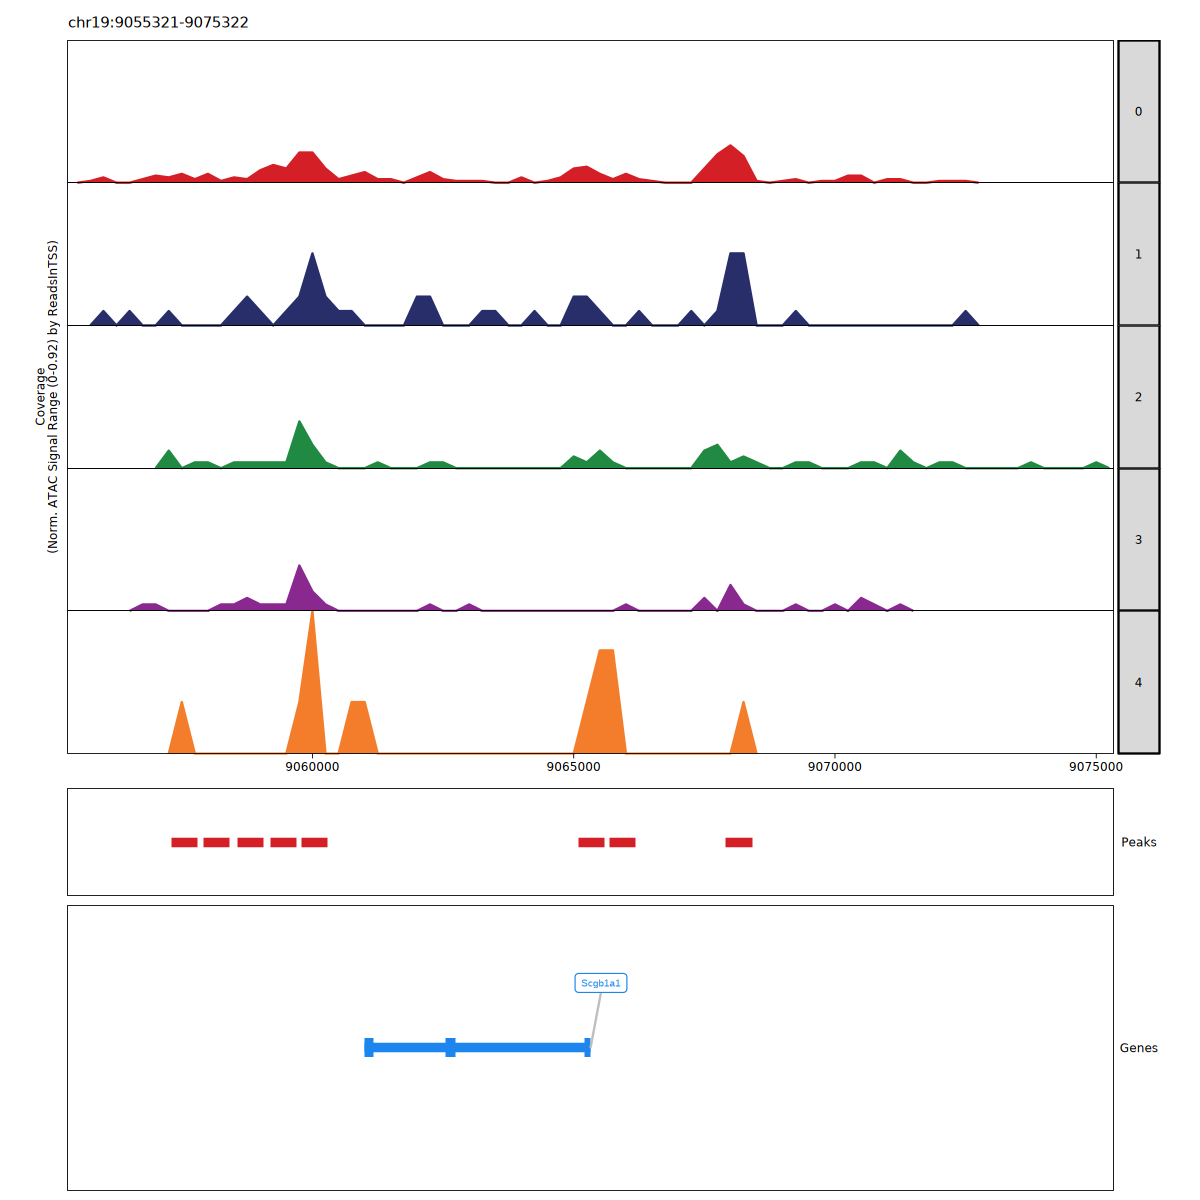

In [39]:
grid::grid.newpage()
grid::grid.draw(p$Scgb1a1)

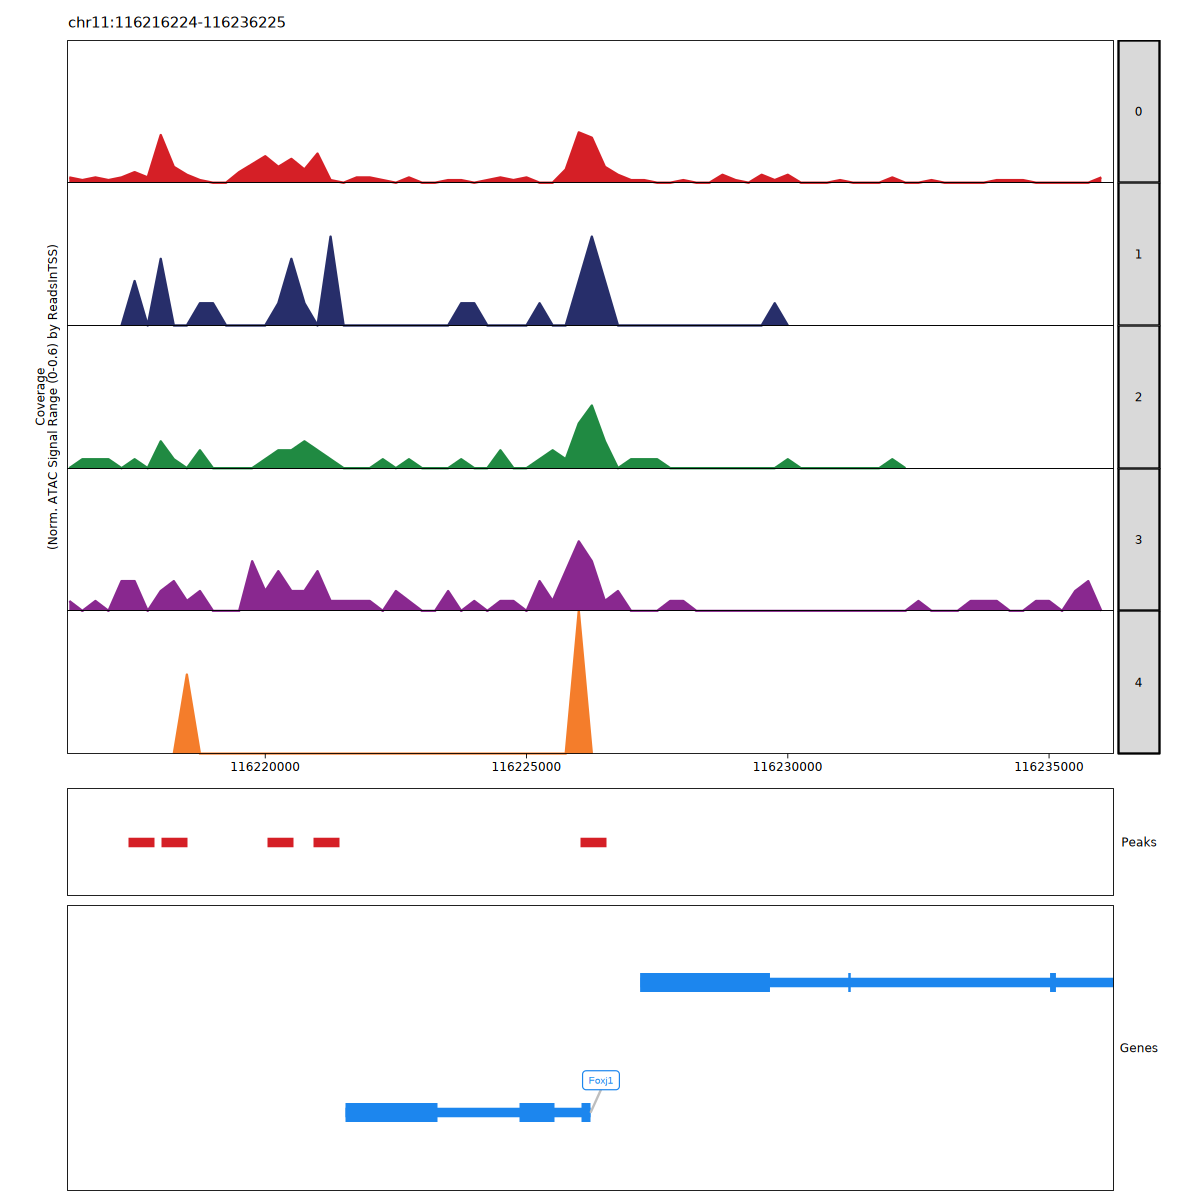

In [40]:
grid::grid.newpage()
grid::grid.draw(p$Foxj1)

In [43]:
## Save data
saveArchRProject(ArchRProj = proj)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/10_create_archr_project 
samples(1): mouse
sampleColData names(1): ArrowFiles
cellColData names(16): Sample TSSEnrichment ... FRIP Clusters
numberOfCells(1): 2024
medianTSS(1): 12.572
medianFrags(1): 5788.5

In [42]:
saveRDS(markersGS, file = file.path(out_dir, "markersGS.rds"))

In [44]:
## Session information
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_access/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.6               hexbin_1.28.5              
 [3] circlize_0.4.16       